# Análisis de los datos

In [1]:
from extraccion import minioFunctions as mf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Se presenta un análisis detallado de las variables regresoras que serán empleadas para el modelo que predice el FRP de un incendio dada una latitud y longitud, así como las correlaciones entre ellas y con la variable objetivo

### **Caracteristicas de las variables**

In [2]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/Modelo_Incendios_{k}.parquet", type="df")
    l_f.append(dataf)
dataFrame = pd.concat(l_f, ignore_index=True)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


In [3]:
df_final = dataFrame.copy()
df_final = df_final.drop(columns = ['count', 'date_last', 'frp_sum', 'date', 'final', 'duration_days'])

**COMPOSICIÓN DEL DATASET**

Las variables son:

In [4]:
print(f"Variables: {df_final.columns}")

Variables: Index(['lat', 'lon', 'frp_mean', 'area_ha', 'elevacion_centro', 'grados',
       'porcentaje', 'temp_mean', 'temp_max', 'temp_min', 'humidity_mean',
       'precipitation', 'wind_speed_max', 'wind_gusts_max', 'pressure_mean',
       'cloud_cover', 'radiation', 'evapotranspiration', 'sunshine_seconds',
       'NDVI', 'NDWI'],
      dtype='str')


Total de incendios:

In [5]:
print(f"Total: {len(df_final)} incendios")

Total: 2684 incendios


Representación primeras filas del dataset:

In [6]:
print(df_final.head(10))

         lat        lon    frp_mean  area_ha  elevacion_centro     grados  \
0  35.026970  32.472335  100.760000   126.14        238.054031   6.640842   
1  35.038019  -5.644138  104.867143  2506.15        185.857239  10.259732   
2  35.110292  -5.739932  115.258889  3904.65        484.057281   6.400329   
3  35.174872  -6.158635   67.302500    50.31         35.344204   0.644440   
4  35.241360  -5.424180   57.190000    14.06       1278.932373  31.858154   
5  35.276600  -5.796210  106.085000    28.12        285.291290   5.243001   
6  35.285883  -6.052637  116.863333    93.34        201.705490   1.786543   
7  35.292369  -5.486675  128.141579  1654.15       1027.844238  15.932363   
8  35.300950   5.736108   62.660000    47.21        785.087524  19.957603   
9  35.325930  33.059080   57.460000    28.12         96.610001   9.160646   

   porcentaje  temp_mean  temp_max  temp_min  ...  precipitation  \
0   11.642637       26.1      29.8      23.9  ...            0.0   
1   18.100486   

**VARIABLE OBJETIVO**

La varible objetivo es una variable numérica continua. 

Esta variable es el frp_mean, y representa la potencia radiactiva del fuego, medida como la energía liberada por unidad de tiempo (MW)

In [7]:
print(df_final['frp_mean'])

0       100.760000
1       104.867143
2       115.258889
3        67.302500
4        57.190000
           ...    
2679    112.500000
2680     97.354000
2681    102.190000
2682     61.230000
2683    106.640000
Name: frp_mean, Length: 2684, dtype: float64


**INFORMACIÓN ESTADÍSTICA DE LAS VARIABLES**

Eliminamos latitud y longitud, ya que se hizo un análisis en el notebook para el problema 1, en el que se observan las zonas de incendio.

Además, estas variables no serán empleadas en el modelo.

In [8]:
df = df_final.drop(columns = ['lat', 'lon'])
df.describe()

,frp_mean,area_ha,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
count,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.00000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000,2684.000000
mean,87.030801,445.409579,343.301935,6.381871,11.576958,20.826155,27.152347,14.736885,49.988450,0.17418,18.570156,40.385209,977.745790,22.631893,22.511818,5.453823,43871.591185,0.381773,-0.422867
std,40.517818,2923.873259,385.728633,7.854373,14.906287,8.870533,9.216697,8.515210,14.326378,0.95756,6.395000,12.771719,42.533065,24.118699,5.539608,2.183343,6441.131688,0.210014,0.169681
min,50.030000,11.030000,-4.045881,0.001912,0.003337,-7.900000,-5.200000,-9.600000,9.000000,0.00000,3.700000,14.000000,718.400000,0.000000,3.560000,0.440000,0.000000,-0.335687,-0.844250
25%,60.887500,14.060000,78.072485,0.578994,1.010570,15.700000,21.600000,9.800000,40.000000,0.00000,13.900000,31.700000,957.900000,2.000000,18.645000,3.807500,40114.925000,0.211150,-0.540684
50%,74.906250,28.120000,188.258316,2.948442,5.150549,23.500000,29.400000,17.400000,50.000000,0.00000,17.800000,38.900000,993.700000,14.000000,23.915000,5.730000,45808.500000,0.345034,-0.419658
75%,100.568026,83.390000,502.613708,9.462526,16.667032,27.400000,33.800000,20.925000,60.000000,0.00000,22.300000,47.500000,1007.100000,36.000000,26.992500,6.980000,48404.365000,0.539487,-0.316495
max,607.340000,75446.430000,2908.075684,58.684683,164.372099,39.000000,48.000000,33.500000,93.000000,20.10000,47.900000,106.200000,1040.900000,100.000000,31.270000,12.360000,68808.280000,0.901769,1.000000


**DISTRIBUCIÓN DE LAS VARIABLES**

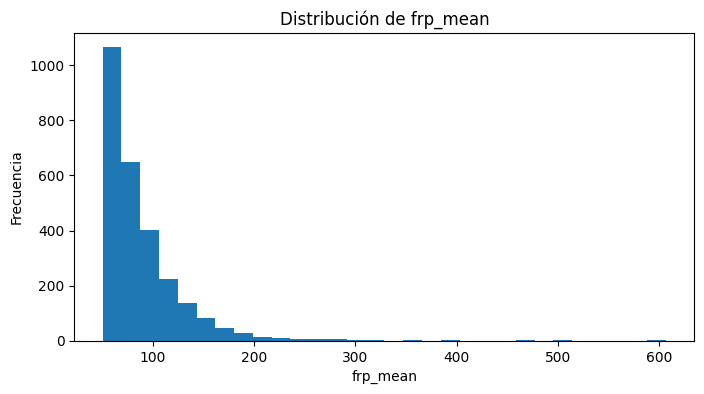

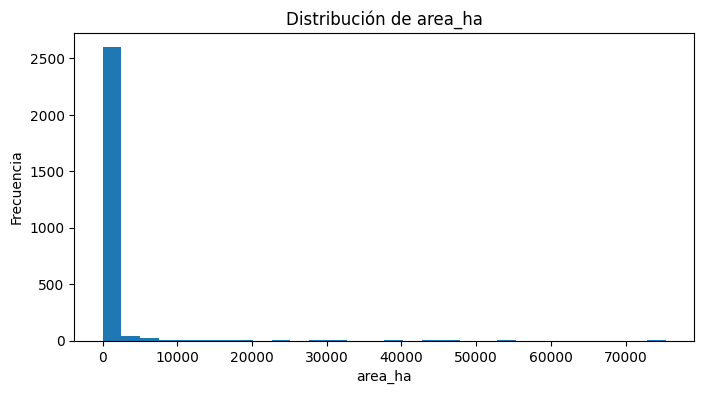

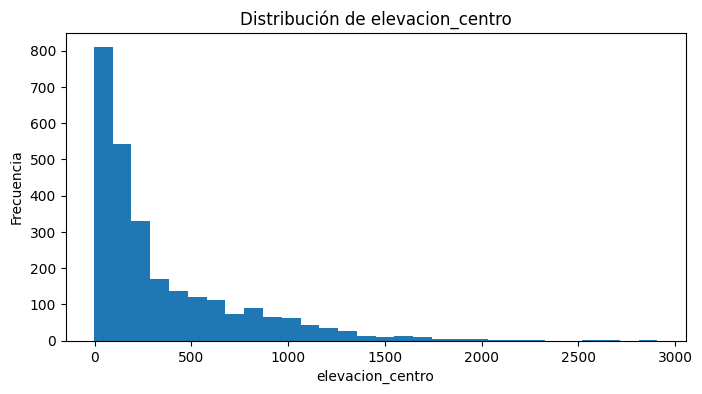

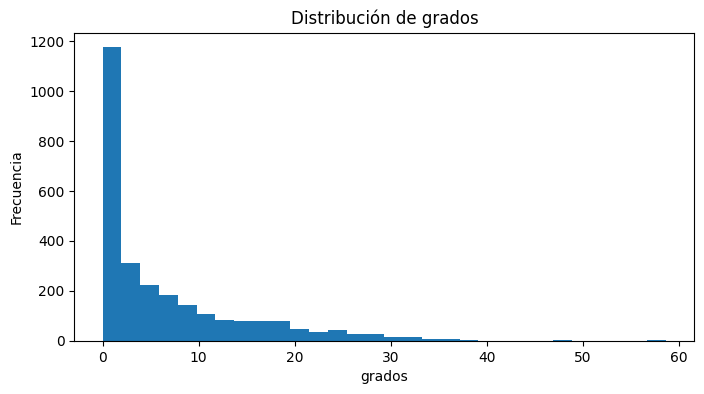

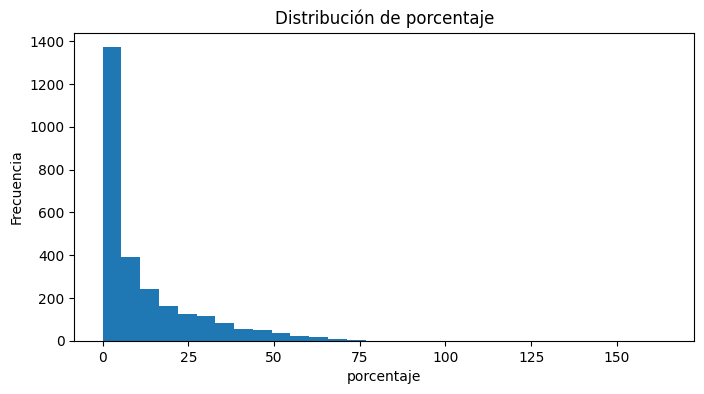

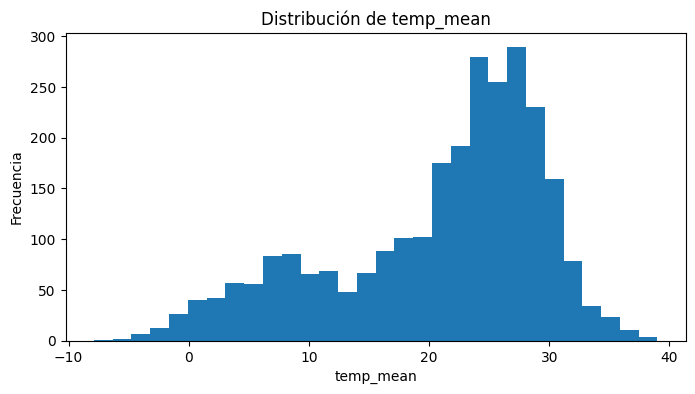

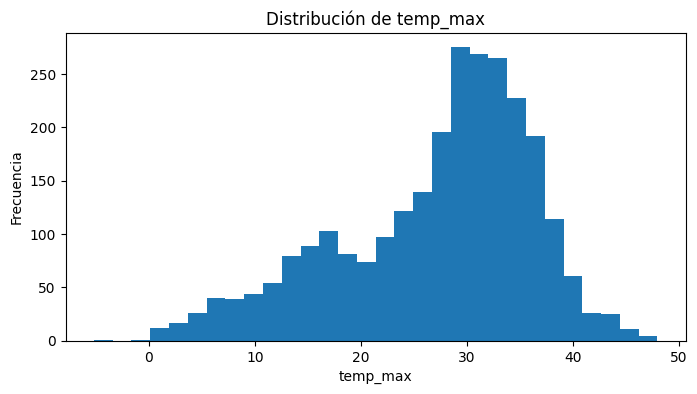

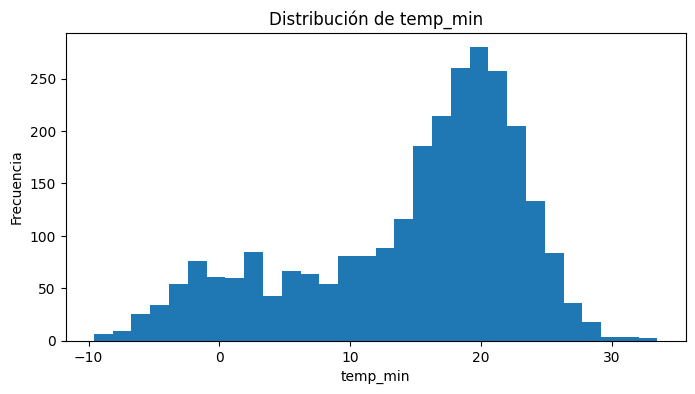

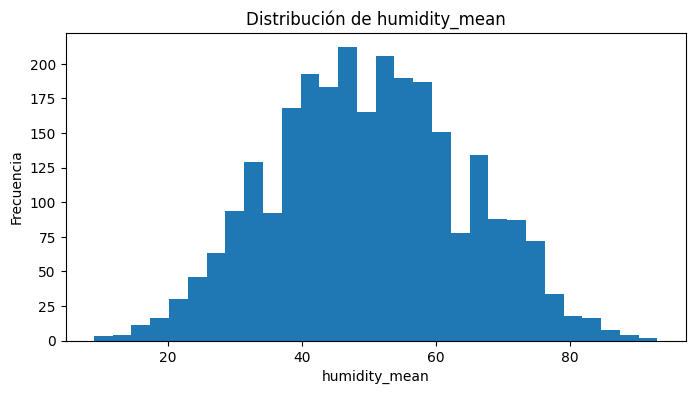

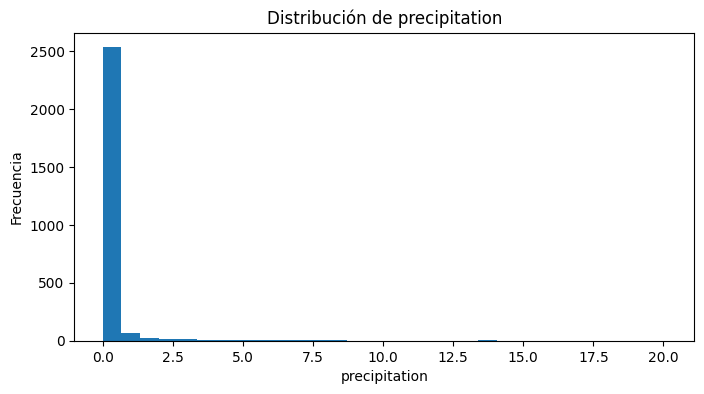

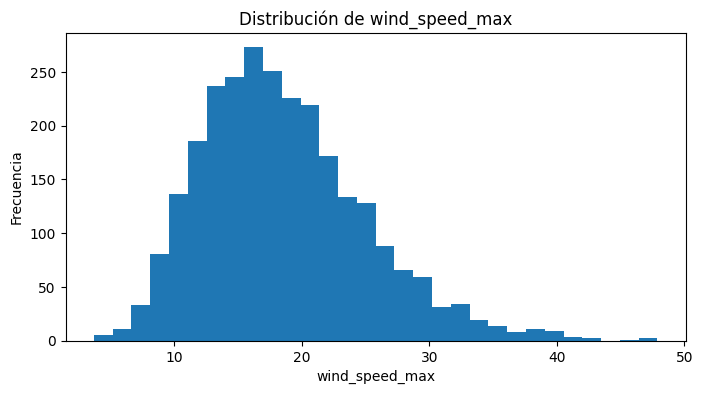

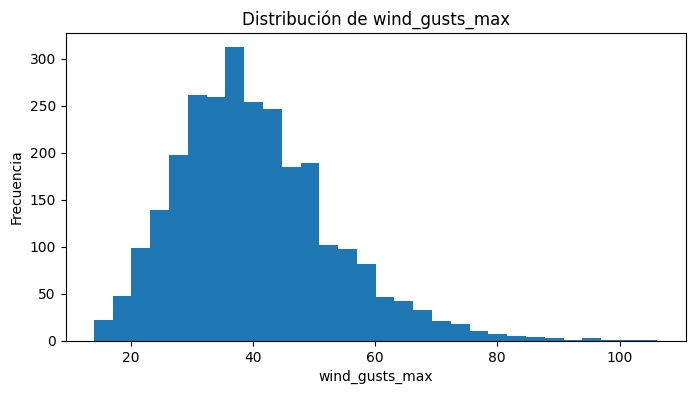

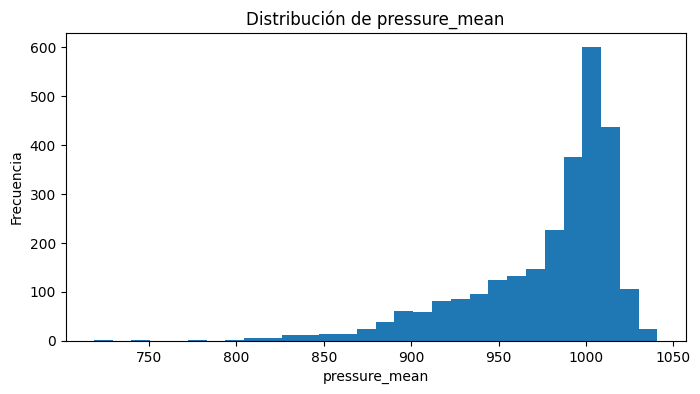

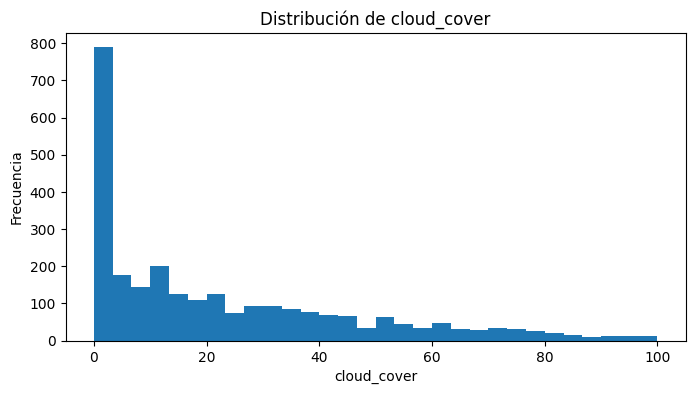

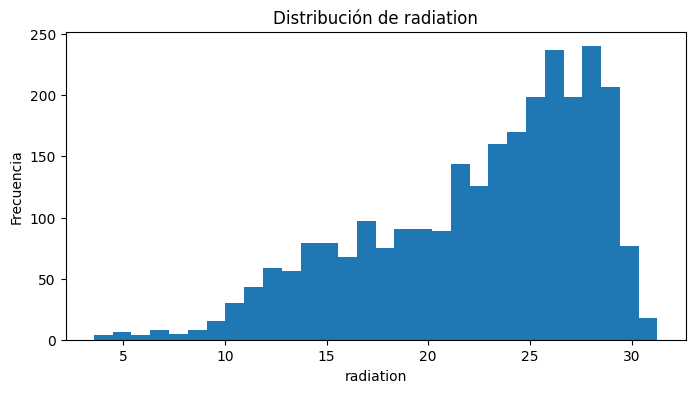

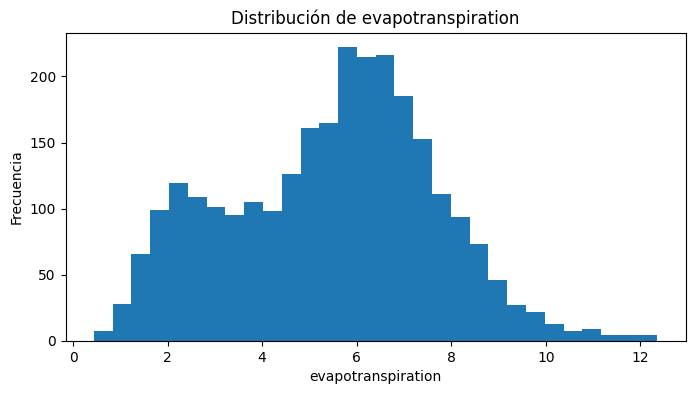

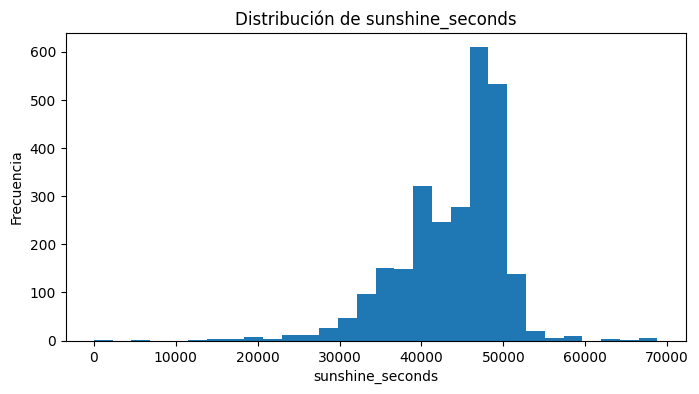

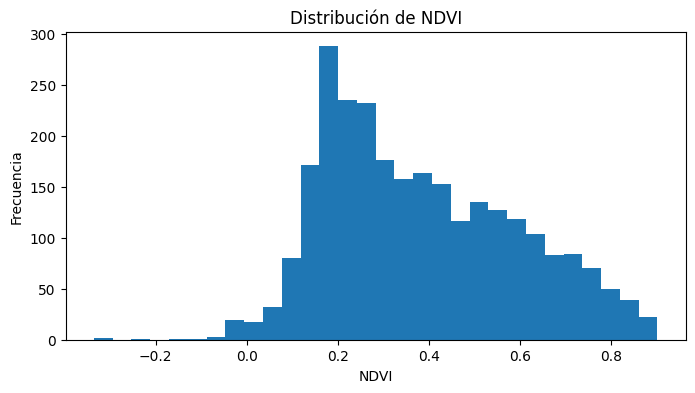

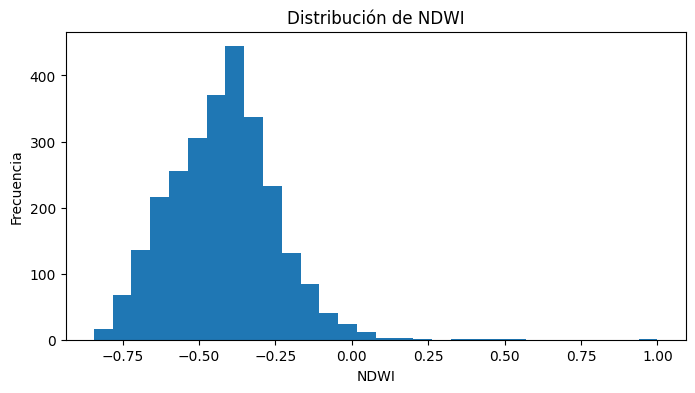

In [45]:
for col in df_final.columns:
    plt.figure(figsize=(8, 4))
    df_final[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.grid(False)
    plt.show()

Se observa que la variable objetivo tiene muchas observaciones con valores altos, y solo algunas con valores bajos. 

Se debe tener en cuenta porque hay modelos que no son robustos a la presencia de outliers.

**ANÁLISIS DE LA PRESENCIA DE OUTLIERS**

Solo se realiza el estudio de outliers para hectáreas y frp porque para el resto de variables fue realizado en el notebook del problema 1.

In [48]:
def detectar_outliers(data, columna):
    Q1 = data[columna].quantile(0.25)
    Q3 = data[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = data[(data[columna] < limite_inf) | (data[columna] > limite_sup)]
    return outliers, limite_inf, limite_sup

for col in ['frp_mean', 'area_ha']:
    outliers, limite_inf, limite_sup = detectar_outliers(df_final, col)
    print(f"Variable {col}: Detectados {len(outliers)} outliers (fuera del rango {limite_inf:.2f} - {limite_sup:.2f})", '\n')

Variable frp_mean: Detectados 129 outliers (fuera del rango 1.37 - 160.09) 

Variable area_ha: Detectados 433 outliers (fuera del rango -89.94 - 187.38) 



Hacemos un análisis de dónde tenemos esos outliers. Para ello usaremos el df general, para poder dibujar el mapa de Europa:

In [5]:
l_f = []
for k in [2022, 2023,2024, 2025]:
    print(f"Analizando el año {k}:")
    dataf = mf.bajar_fichero(mf.crear_cliente(), path_server=f"grupo3/cleaned/modelo_General_{k}.parquet", type="df")
    l_f.append(dataf)

dataFrame_general = pd.concat(l_f, ignore_index=True)

Analizando el año 2022:
Dataframe importado correctamente
Analizando el año 2023:
Dataframe importado correctamente
Analizando el año 2024:
Dataframe importado correctamente
Analizando el año 2025:
Dataframe importado correctamente


**1. Outliers en area_ha:**

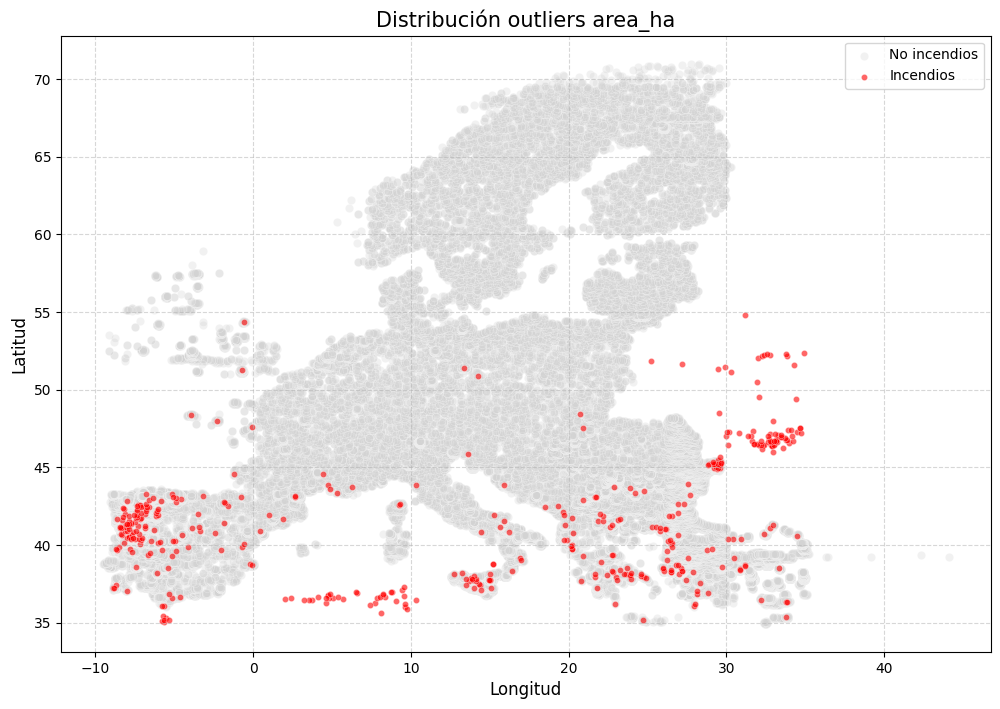

In [6]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['area_ha'] > 187.38]
datos_no_inc = dataFrame_general[dataFrame_general['final'] == 0]

sns.scatterplot(data=datos_no_inc, x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_dist, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución outliers area_ha', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**2. Outliers en frp_mean (variable objetivo):**

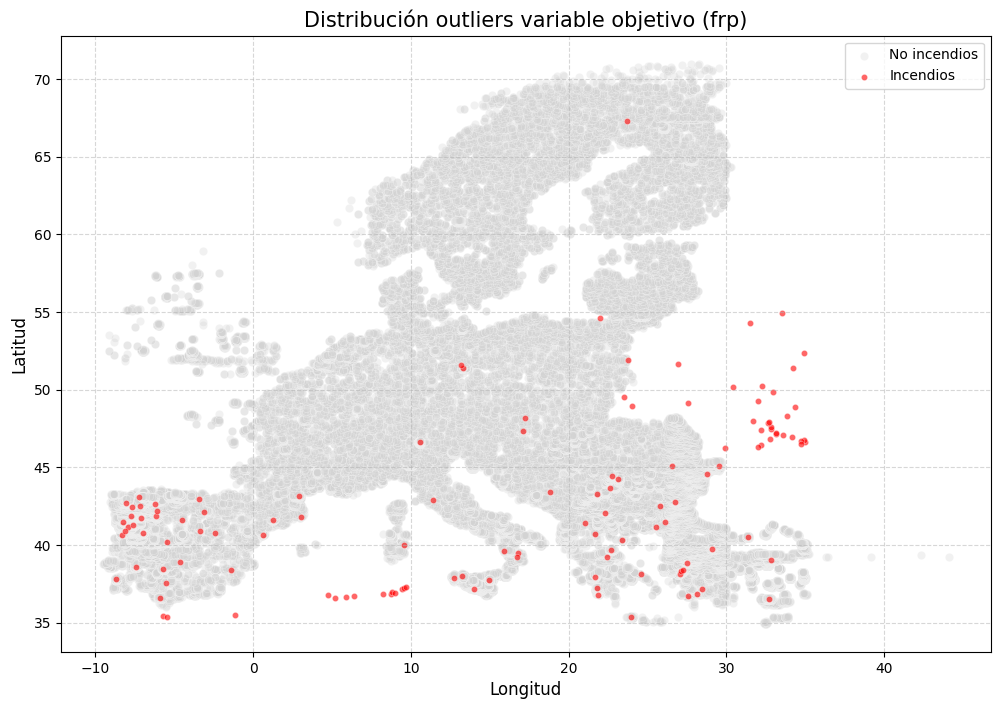

In [7]:
plt.figure(figsize=(12, 8))

df_dist = df_final[df_final['frp_mean'] > 160.09]
datos_no_inc = dataFrame_general[dataFrame_general['final'] == 0]

sns.scatterplot(data=datos_no_inc, x='lon', y='lat', color='lightgrey', alpha=0.3, label='No incendios')

sns.scatterplot(data=df_dist, x='lon', y='lat', color='red', alpha=0.6, s=20, label='Incendios')

plt.title('Distribución outliers variable objetivo (frp)', fontsize=15)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Los outliers detectados son completamente normales. La mayoría se encuentran en las zonas de Galicia y norte de Portugal, así como en Sicilia y el norte de África. Propios de la región Mediterránea y Estépica.

**CORRELACIONES ENTRE LAS VARIABLES REGRESORAS**

Posteriormente, se realizará un análisis de las correlaciones con la variable objetivo.

In [32]:
df2 = df_final.drop(columns = ['frp_mean'])
df2.corr().style.background_gradient(cmap='coolwarm')

,area_ha,elevacion_centro,grados,porcentaje,temp_mean,temp_max,temp_min,humidity_mean,precipitation,wind_speed_max,wind_gusts_max,pressure_mean,cloud_cover,radiation,evapotranspiration,sunshine_seconds,NDVI,NDWI
area_ha,1.000000,0.105156,0.089743,0.087045,0.041445,0.039931,0.045371,-0.075050,-0.003021,0.052450,0.088007,-0.103408,-0.016069,0.033474,0.067543,0.007119,0.087104,-0.080337
elevacion_centro,0.105156,1.000000,0.535326,0.522989,-0.010133,0.013722,-0.029360,-0.219014,0.007241,-0.204548,0.075747,-0.988645,-0.060209,0.096624,0.024067,-0.034111,0.182218,-0.157458
grados,0.089743,0.535326,1.000000,0.996191,0.152225,0.152592,0.162057,-0.179844,0.004787,-0.054861,0.232956,-0.552529,-0.093989,0.153912,0.145596,0.015510,0.328979,-0.262491
porcentaje,0.087045,0.522989,0.996191,1.000000,0.144030,0.143467,0.154290,-0.170604,0.006967,-0.056809,0.225446,-0.539995,-0.089388,0.147259,0.136843,0.014806,0.317363,-0.251332
temp_mean,0.041445,-0.010133,0.152225,0.144030,1.000000,0.984100,0.980180,-0.557174,-0.027415,0.173253,0.229754,-0.072509,-0.242503,0.729772,0.891209,0.603460,0.293255,-0.354036
temp_max,0.039931,0.013722,0.152592,0.143467,0.984100,1.000000,0.939003,-0.586063,-0.048737,0.127813,0.185264,-0.092547,-0.266270,0.722886,0.883534,0.593485,0.287590,-0.348474
temp_min,0.045371,-0.029360,0.162057,0.154290,0.980180,0.939003,1.000000,-0.496032,0.004634,0.232560,0.290416,-0.054522,-0.206854,0.684270,0.862223,0.557532,0.293164,-0.351291
humidity_mean,-0.075050,-0.219014,-0.179844,-0.170604,-0.557174,-0.586063,-0.496032,1.000000,0.202989,-0.153200,-0.233631,0.241439,0.308069,-0.503721,-0.716453,-0.352425,-0.153515,0.169244
precipitation,-0.003021,0.007241,0.004787,0.006967,-0.027415,-0.048737,0.004634,0.202989,1.000000,0.062862,0.070135,-0.021673,0.225267,-0.123383,-0.112042,-0.133625,0.026572,-0.010142
wind_speed_max,0.052450,-0.204548,-0.054861,-0.056809,0.173253,0.127813,0.232560,-0.153200,0.062862,1.000000,0.858746,0.164074,0.081976,0.086053,0.354610,-0.007214,0.015849,-0.021726


<Axes: >

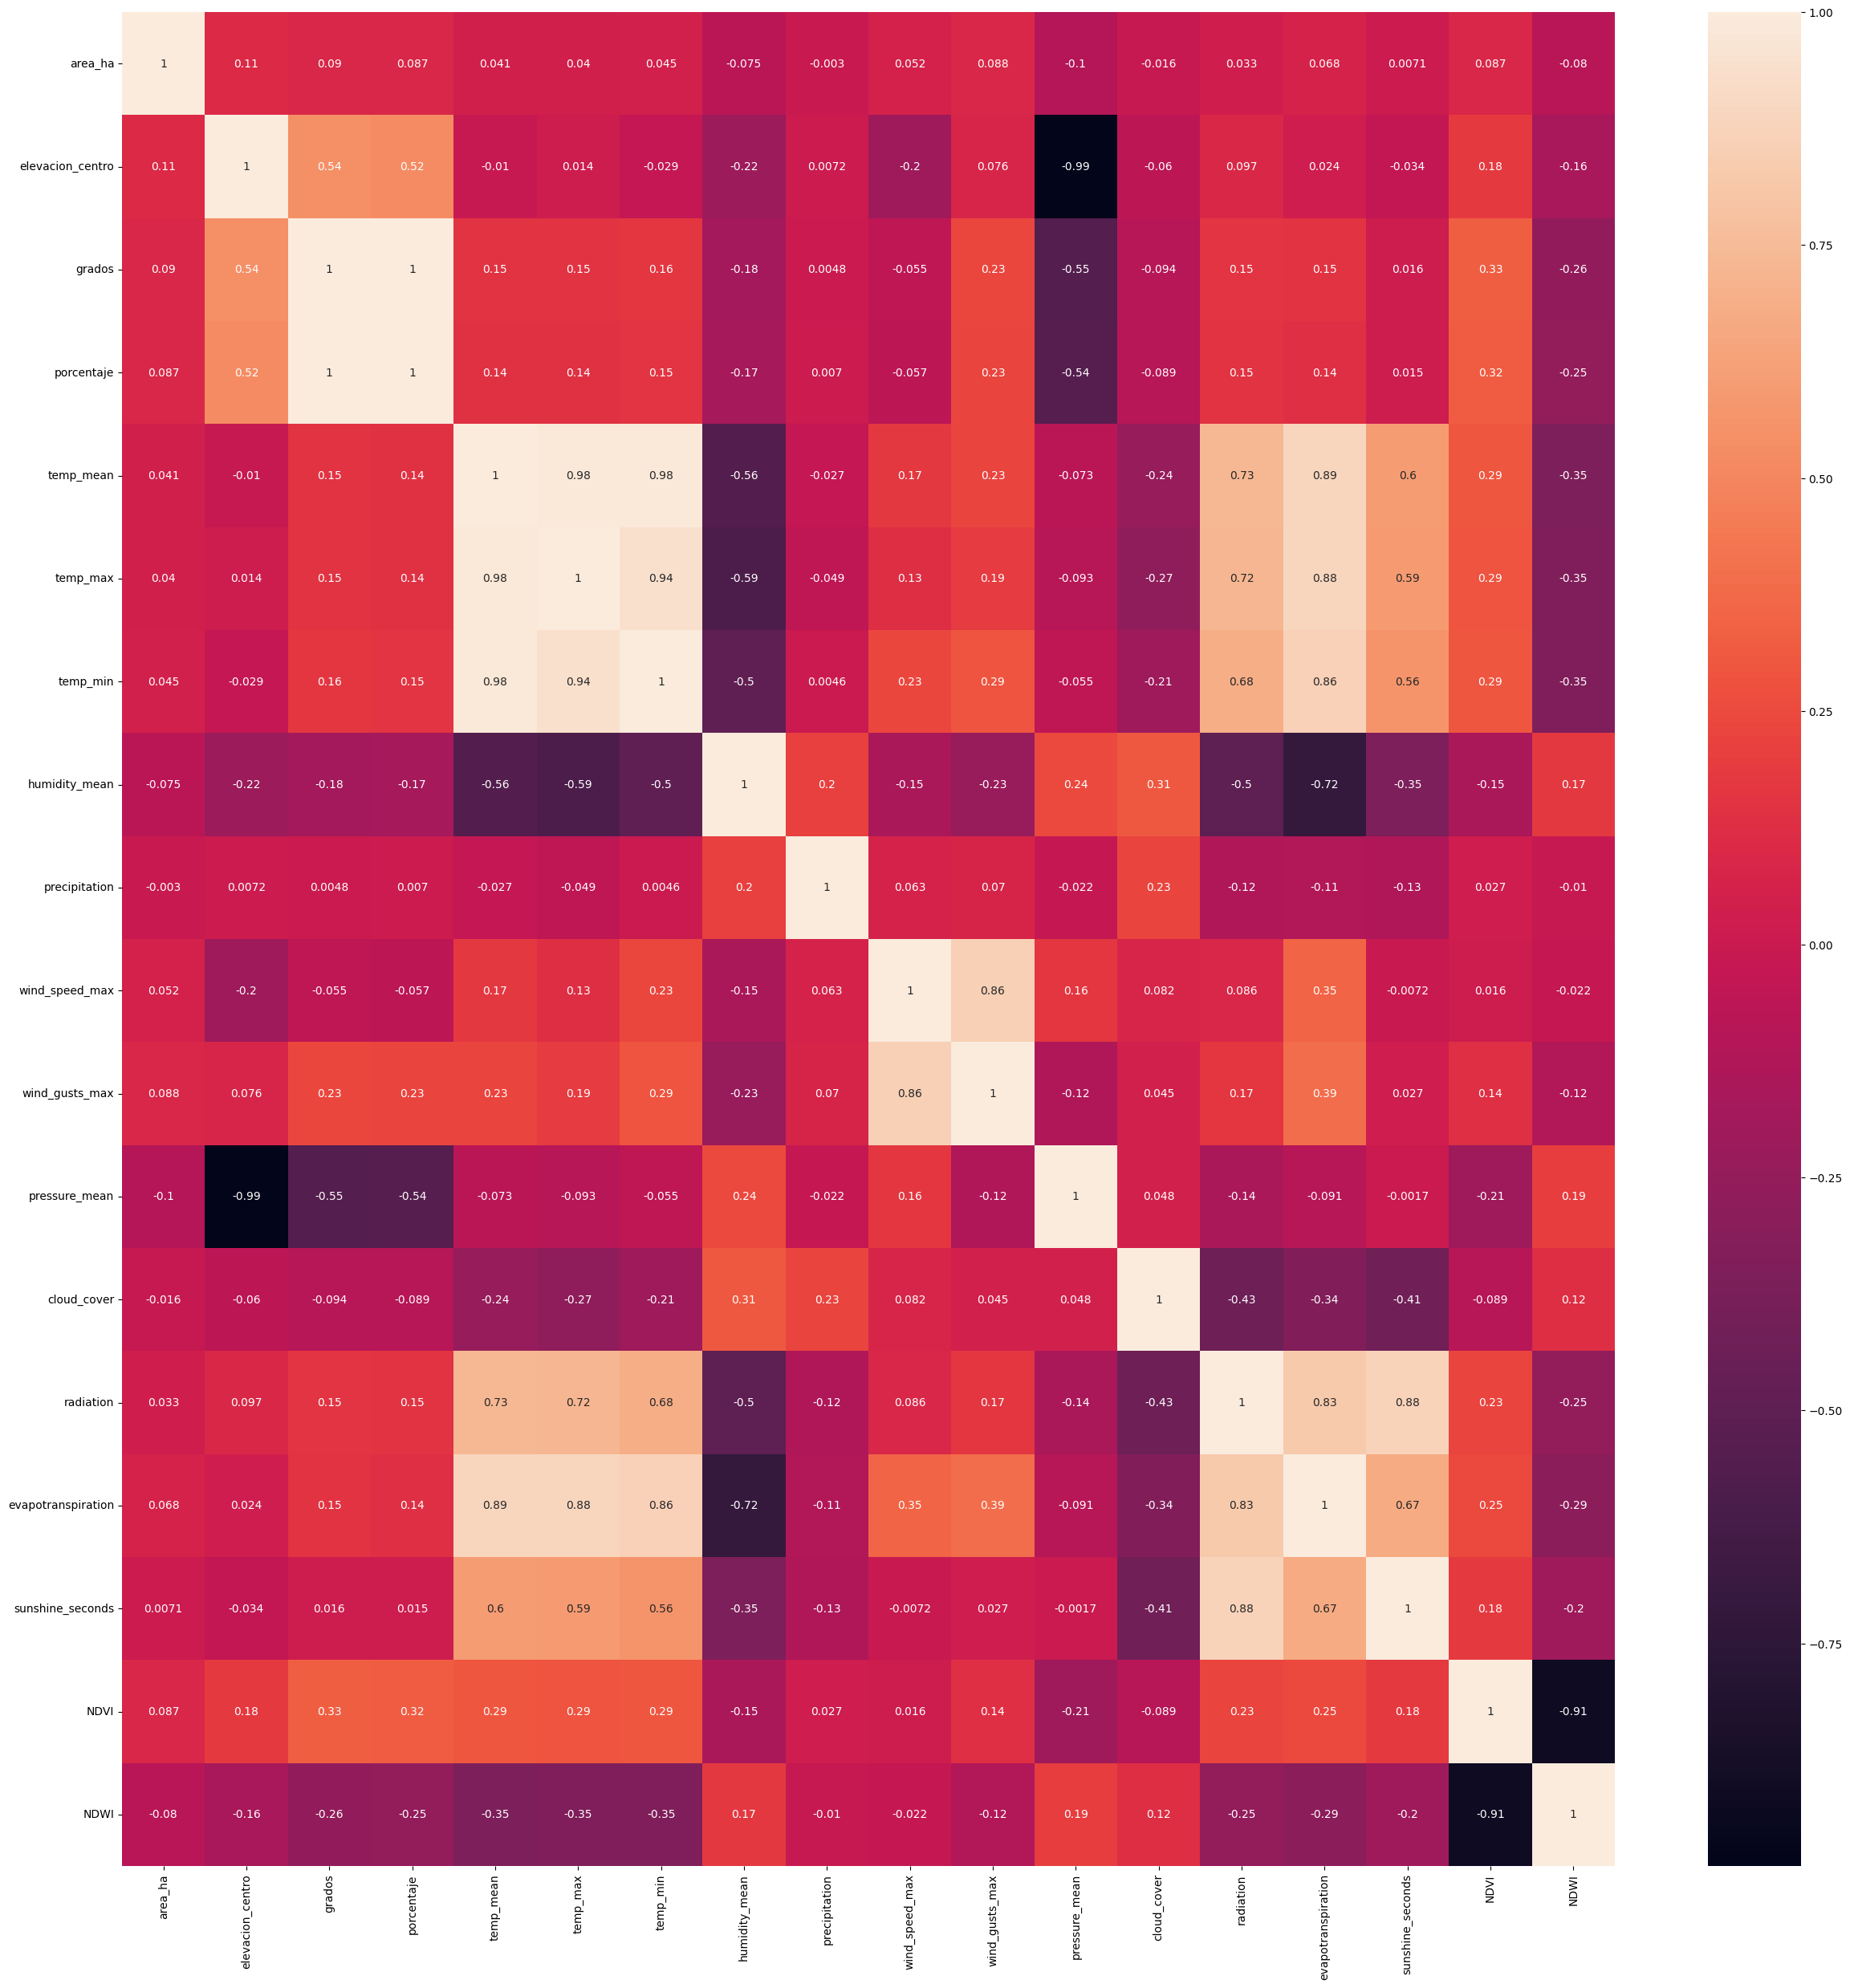

In [33]:
plt.figure(figsize=(30, 30))
sns.heatmap(df2.corr(), annot=True)

**Conclusiones:**

Aún no detallamos conclusiones, en previsión de que este no es el dataset final.

**CORRELACIÓN DE LAS VARIABLES REGRESORAS CON LA VARIABLE OBJETIVO**

In [35]:
correlaciones = df_final.corr()
corr_objetivo = correlaciones['frp_mean'].drop(labels=['frp_mean']).sort_values(ascending=False)
df_corr_final = corr_objetivo.to_frame(name='Coeficiente de correlación')
df_corr_final

,Coeficiente de correlación
wind_gusts_max,0.136156
evapotranspiration,0.132261
grados,0.132179
porcentaje,0.128540
NDVI,0.126012
temp_max,0.114795
temp_mean,0.111792
temp_min,0.106737
radiation,0.099536
wind_speed_max,0.091750


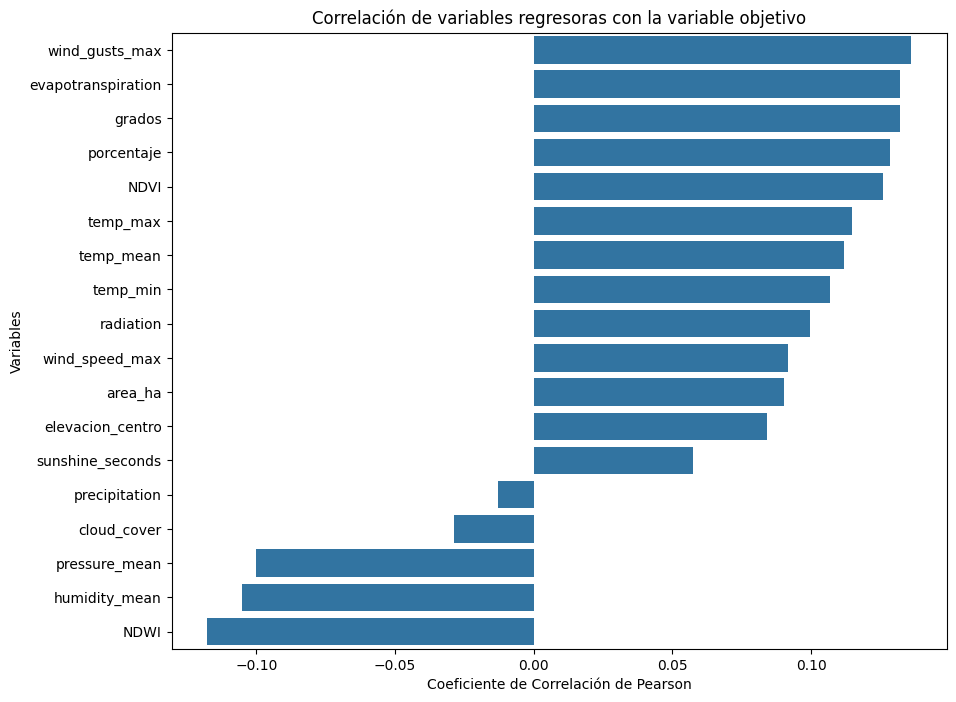

In [36]:
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_objetivo.values, y=corr_objetivo.index)
plt.title('Correlación de variables regresoras con la variable objetivo')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.ylabel('Variables')
plt.show()

**Conclusión:**

Se observa que las variables más correlacionadas con la variable objetivo son wind_gusts_max, evapotranspiration, grados, porcentaje, NDVI, las variables de temperatura y NDWI, con correlación negativa. 

Aún así, las correlaciones son bajas, puesto que ninguna representa un correlación mayor que 0.15. Esto es un indicio de que no existe relación lineal entre la variable objetivo y las variables regresoras. Podría ser problemático plantear un modelo de regresión lineal, puesto que este no conseguiría capturar realmente patrones. 

Por ejemplo, el posible que la temperatura no afecte al FRP de forma lineal, sino que a partir de ciertos grados el riesgo se dispare exponencialmente. O incluso que una variable por sí sola no influya directamente en el frp, sino que esta influencia se vea incrementada con la interacción con otras variables.